In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

In [2]:
financial_df=pd.read_csv("goldmasn sachs column added.csv")

In [5]:
print(financial_df.head())

   TransactionID CustomerID AccountID AccountType TransactionType  \
0              4   CUST8529  ACC32212     Current         Deposit   
1              4   CUST2699  ACC55331        Loan         Deposit   
2              4   CUST3315  ACC33287      Credit         Deposit   
3              5   CUST7345  ACC67713     Savings         Deposit   
4              6   CUST3378  ACC11188        Loan         Deposit   

           Product    Firm   Region    Manager TransactionDate  \
0      Mutual Fund  Firm E     West  Manager 4      30-12-2023   
1    Personal Loan  Firm A     East  Manager 2      10-02-2023   
2    Personal Loan  Firm B    South  Manager 3      17-04-2023   
3  Savings Account  Firm A  Central  Manager 1      08-02-2024   
4        Home Loan  Firm A     East  Manager 2      04-05-2023   

   TransactionAmount1  TransactionAmount  AccountBalance  RiskScore  \
0         94602.32081        94602.32081     92272.73895   0.681074   
1         24457.70658        24457.70658     7

In [ ]:
## Before going with the data I have created a separate column in data set as TransactionAmount1 
## in which i have considered the withdrawal,payment,and transfer type as a negative value in transaction amount and 
## deposit type as positive transaction amount .

## Task 1 Data Cleaning and Formatting

### Remove/treat any special characters or non-numeric entries from financial fields

In [29]:
f=['TransactionAmount1', 'AccountBalance', 'RiskScore','CreditRating','TenureMonths']
financial_df[f] = (
    financial_df[f].apply(lambda col: (col.astype(str).str.replace(r'\((.*?)\)', r'-\1', regex=True).str.replace(r'[^\d.-]', '', regex=True).replace('', pd.NA).astype(float)))
)

In [30]:
### there are no special characters
print(financial_df.head())      

   TransactionID CustomerID AccountID AccountType TransactionType  \
0              4   CUST8529  ACC32212     Current         Deposit   
1              4   CUST2699  ACC55331        Loan         Deposit   
2              4   CUST3315  ACC33287      Credit         Deposit   
3              5   CUST7345  ACC67713     Savings         Deposit   
4              6   CUST3378  ACC11188        Loan         Deposit   

           Product    Firm   Region    Manager TransactionDate  ...  \
0      Mutual Fund  Firm E     West  Manager 4      2023-12-30  ...   
1    Personal Loan  Firm A     East  Manager 2      2023-02-10  ...   
2    Personal Loan  Firm B    South  Manager 3      2023-04-17  ...   
3  Savings Account  Firm A  Central  Manager 1      2024-02-08  ...   
4        Home Loan  Firm A     East  Manager 2      2023-05-04  ...   

   AccountBalance  RiskScore  CreditRating  TenureMonths  Credit  Debit  year  \
0         92272.0   0.681074         353.0         191.0   94602      0  2023

### Convert currency amounts into numerical format

In [27]:
financial_df['TransactionAmount'] = financial_df['TransactionAmount'].astype(int)
financial_df['TransactionAmount1'] = financial_df['TransactionAmount1'].astype(int)

In [28]:
financial_df['AccountBalance'] = financial_df['AccountBalance'].astype(int)

In [26]:
## converted the float numerical into integer data type for better understanding
financial_df[['TransactionAmount1', 'AccountBalance']].dtypes

TransactionAmount1    int64
AccountBalance        int64
dtype: object

### Validate and format date columns

In [11]:
## formatted the date column
financial_df['TransactionDate'] = pd.to_datetime(
    financial_df['TransactionDate'],
    format='%d-%m-%Y',
    errors='coerce'
)

In [14]:
print (financial_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   TransactionID       800 non-null    int64         
 1   CustomerID          800 non-null    object        
 2   AccountID           800 non-null    object        
 3   AccountType         800 non-null    object        
 4   TransactionType     800 non-null    object        
 5   Product             800 non-null    object        
 6   Firm                800 non-null    object        
 7   Region              800 non-null    object        
 8   Manager             800 non-null    object        
 9   TransactionDate     800 non-null    datetime64[ns]
 10  TransactionAmount1  800 non-null    int64         
 11  TransactionAmount   800 non-null    int64         
 12  AccountBalance      800 non-null    int64         
 13  RiskScore           800 non-null    float64       

### Ensure account types and transaction categories are standardized

In [17]:
## check the transaction type and account type are in standardized 
financial_df[['AccountType', 'TransactionType']].dtypes

AccountType        object
TransactionType    object
dtype: object

## Task 2: Descriptive Transactional Analysis

### Calculate monthly and yearly summaries of total credits, debits, and net transaction volume

In [18]:
## Calculated a separte columns for credit and debit
financial_df["Credit"] = financial_df["TransactionAmount1"].where(financial_df["TransactionType"] == "Deposit", 0)
financial_df["Debit"]  = financial_df["TransactionAmount1"].where(financial_df["TransactionType"] == "Withdrawal", 0)  

In [19]:
## separate columns created foe year and month which will be easier to analysis over a period of time
financial_df['year'] = financial_df['TransactionDate'].dt.year
financial_df['month_name'] = financial_df['TransactionDate'].dt.strftime('%B')


In [20]:
## calculates the net transaction
financial_df['net_transaction'] = financial_df['Credit'] - financial_df['Debit'] 

In [21]:
print(financial_df.head()) 

   TransactionID CustomerID AccountID AccountType TransactionType  \
0              4   CUST8529  ACC32212     Current         Deposit   
1              4   CUST2699  ACC55331        Loan         Deposit   
2              4   CUST3315  ACC33287      Credit         Deposit   
3              5   CUST7345  ACC67713     Savings         Deposit   
4              6   CUST3378  ACC11188        Loan         Deposit   

           Product    Firm   Region    Manager TransactionDate  ...  \
0      Mutual Fund  Firm E     West  Manager 4      2023-12-30  ...   
1    Personal Loan  Firm A     East  Manager 2      2023-02-10  ...   
2    Personal Loan  Firm B    South  Manager 3      2023-04-17  ...   
3  Savings Account  Firm A  Central  Manager 1      2024-02-08  ...   
4        Home Loan  Firm A     East  Manager 2      2023-05-04  ...   

   TransactionAmount  AccountBalance  RiskScore  CreditRating  TenureMonths  \
0              94602           92272   0.681074         353.0         191.0   


### Plot trends in total credits vs. debits over time

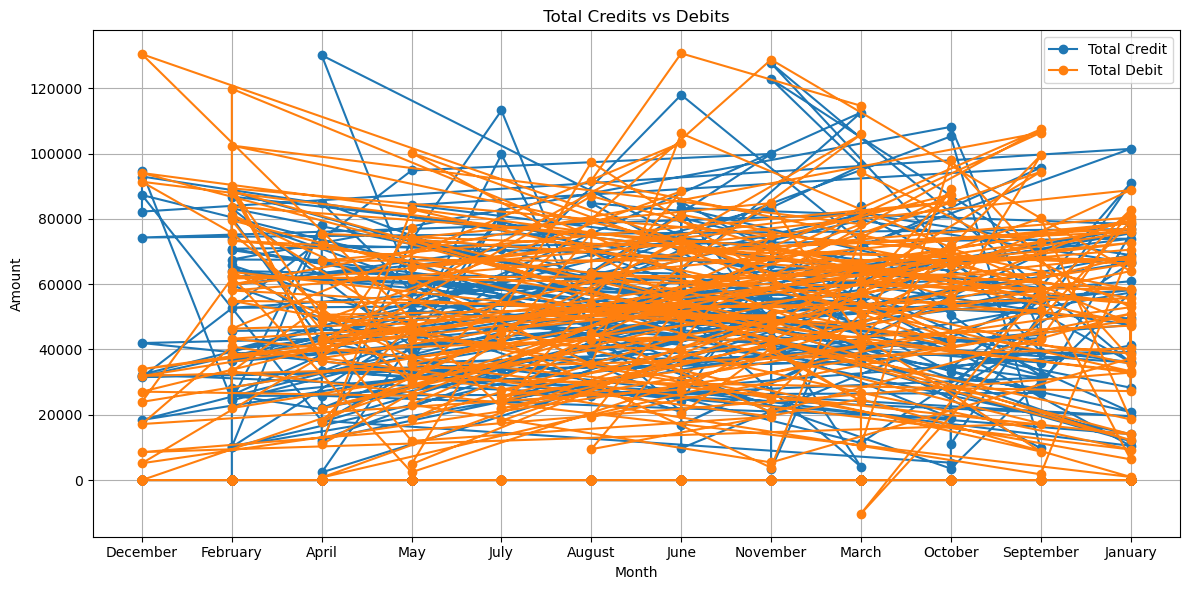

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(financial_df['month_name'], financial_df['Credit'], marker='o', label='Total Credit')
plt.plot(financial_df['month_name'], financial_df['Debit'], marker='o', label='Total Debit')
plt.title(' Total Credits vs Debits ')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Identify top and bottom performing accounts based on net inflow

In [31]:
## calculated the net amount
financial_df["NetAmount"] = financial_df["TransactionAmount1"].where(financial_df["TransactionType"]=="Deposit",financial_df["TransactionAmount1"])

In [32]:
## net inflow per account
net_inflow_per_account = financial_df.groupby("AccountID")["NetAmount"].sum()

In [33]:
## top and botton net inflow accounts
top_account = net_inflow_per_account.idxmax()       
bottom_account = net_inflow_per_account.idxmin()

In [34]:
print("Top performing account:", top_account, "Net inflow:", net_inflow_per_account[top_account])
print("Bottom performing account:", bottom_account, "Net inflow:", net_inflow_per_account[bottom_account])

Top performing account: ACC46655 Net inflow: 744397.0
Bottom performing account: ACC43771 Net inflow: 14033.0


### Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions

In [39]:
dff = financial_df.sort_values(["AccountID", "TransactionDate"])

dff["gap_days"] = financial_df.groupby("AccountID")["TransactionDate"].diff().dt.days
dff

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,Credit,Debit,year,month_name,net_transaction,NetAmount,gap_days
475,73,CUST9209,ACC10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,0.354694,354.0,60.0,0,0,2023,January,0,57310.0,-409.0
24,34,CUST3109,ACC10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,0.206170,611.0,85.0,67555,0,2023,February,67555,67555.0,NaN
113,106,CUST8155,ACC10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,0.736631,573.0,109.0,63248,0,2023,June,63248,63248.0,117.0
172,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,0.371513,697.0,218.0,11366,0,2024,March,11366,11366.0,270.0
753,158,CUST3041,ACC10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,0.748719,557.0,233.0,0,11989,2023,May,-11989,11989.0,-266.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,45,CUST7887,ACC99409,Current,Withdrawal,Home Loan,Firm C,Central,Manager 4,2024-03-22,...,0.329888,565.0,167.0,0,10465,2024,March,-10465,10465.0,174.0
532,135,CUST3015,ACC99549,Savings,Transfer,Credit Card,Firm D,East,Manager 2,2023-04-14,...,0.331102,317.0,157.0,0,0,2023,April,0,30330.0,-195.0
393,195,CUST8416,ACC99549,Loan,Payment,Credit Card,Firm C,West,Manager 1,2023-08-04,...,0.432719,541.0,128.0,0,0,2023,August,0,67346.0,-198.0
419,25,CUST4258,ACC99549,Loan,Transfer,Mutual Fund,Firm E,West,Manager 2,2023-10-26,...,0.552694,767.0,47.0,0,0,2023,October,0,20821.0,83.0


In [40]:
def account_status(gap):
    if pd.isna(gap):
        return "Active"
    else:
        if gap >= 60:
            return "Dormant"
        else:
            return "Active"

dff["account_status"] = dff["gap_days"].apply(account_status)
dff

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,Credit,Debit,year,month_name,net_transaction,NetAmount,gap_days,account_status
475,73,CUST9209,ACC10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,354.0,60.0,0,0,2023,January,0,57310.0,-409.0,Active
24,34,CUST3109,ACC10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,611.0,85.0,67555,0,2023,February,67555,67555.0,NaN,Active
113,106,CUST8155,ACC10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,573.0,109.0,63248,0,2023,June,63248,63248.0,117.0,Dormant
172,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,697.0,218.0,11366,0,2024,March,11366,11366.0,270.0,Dormant
753,158,CUST3041,ACC10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,557.0,233.0,0,11989,2023,May,-11989,11989.0,-266.0,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,45,CUST7887,ACC99409,Current,Withdrawal,Home Loan,Firm C,Central,Manager 4,2024-03-22,...,565.0,167.0,0,10465,2024,March,-10465,10465.0,174.0,Dormant
532,135,CUST3015,ACC99549,Savings,Transfer,Credit Card,Firm D,East,Manager 2,2023-04-14,...,317.0,157.0,0,0,2023,April,0,30330.0,-195.0,Active
393,195,CUST8416,ACC99549,Loan,Payment,Credit Card,Firm C,West,Manager 1,2023-08-04,...,541.0,128.0,0,0,2023,August,0,67346.0,-198.0,Active
419,25,CUST4258,ACC99549,Loan,Transfer,Mutual Fund,Firm E,West,Manager 2,2023-10-26,...,767.0,47.0,0,0,2023,October,0,20821.0,83.0,Dormant


In [44]:
## Visualization
status_counts = dff["account_status"].value_counts()
status_counts

account_status
Active     557
Dormant    243
Name: count, dtype: int64

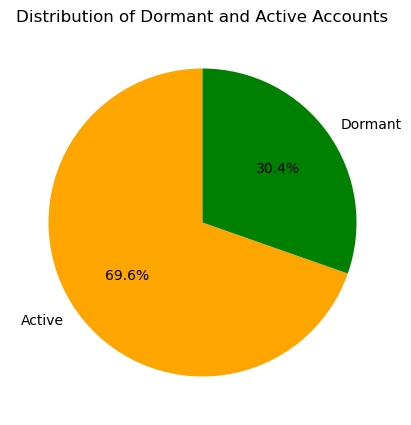

In [45]:
plt.figure(figsize=(5,5))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=["orange", "green"],
    startangle=90
)

plt.title("Distribution of Dormant and Active Accounts")
plt.show()

## Task 3: Customer Profile Building

### Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings

In [18]:
## transaction count
txn_counts = financial_df.groupby("AccountID").size().reset_index(name="TransactionCount")  

In [19]:
## average transaction account for per account
avg_txn_per_account = (
   txn_counts.groupby('AccountID')['TransactionCount']
    .mean()
    .reset_index(name='avg_monthly_txns')
)

In [20]:
## activity level divided into low,high(>=5),medium(>=3)
def activity_level(avg_txns):
    if avg_txns >= 5:
        return 'High'
    elif avg_txns >= 3:
        return 'Medium'
    else:
        return 'Low'

avg_txn_per_account['ActivityLevel'] = avg_txn_per_account['avg_monthly_txns'].apply(activity_level)

In [21]:
financial_df = financial_df.merge(avg_txn_per_account[['AccountID', 'ActivityLevel']],
              on='AccountID',
              how='left')

financial_df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount1,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,ActivityLevel
0,4,CUST8529,ACC32212,Current,Deposit,Mutual Fund,Firm E,West,Manager 4,30-12-2023,94602.32081,94602.32081,92272.73895,0.681074,353,191,High
1,4,CUST2699,ACC55331,Loan,Deposit,Personal Loan,Firm A,East,Manager 2,10-02-2023,24457.70658,24457.70658,71999.33447,0.104918,673,110,Medium
2,4,CUST3315,ACC33287,Credit,Deposit,Personal Loan,Firm B,South,Manager 3,17-04-2023,78277.54877,78277.54877,84289.01710,0.567466,708,22,High
3,5,CUST7345,ACC67713,Savings,Deposit,Savings Account,Firm A,Central,Manager 1,08-02-2024,10108.19625,10108.19625,68650.80576,0.392993,533,216,Medium
4,6,CUST3378,ACC11188,Loan,Deposit,Home Loan,Firm A,East,Manager 2,04-05-2023,45748.34156,45748.34156,113773.11710,-0.155394,538,181,High


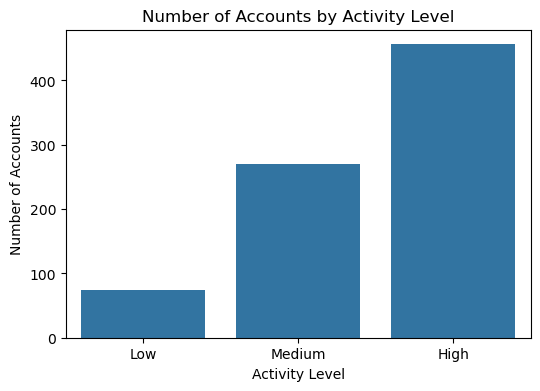

In [23]:
## Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='ActivityLevel', data=financial_df,
              order=['Low', 'Medium', 'High'])
plt.title('Number of Accounts by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Number of Accounts')
plt.show()

In [ ]:
## Insights from graph
## This skew suggests most customers transact frequently, so monitoring and differentiating behavior within  the high-activity segment will be more important than focusing on low-activity accounts.


### Segment customers by average balance and transaction volume

In [58]:
## average balance per customer
avg_balance = (
   financial_df.groupby('CustomerID')['AccountBalance']
      .mean()
      .reset_index(name='avg_balance')
)

In [59]:
## average monthly transaction volume
monthly_txns = (
    financial_df.groupby(['CustomerID', 'month_name'])
      .size()
      .reset_index(name='monthly_txn_count')
)

avg_txn_volume = (
    monthly_txns.groupby('CustomerID')['monthly_txn_count']
    .mean()
    .reset_index(name='avg_monthly_txns')
)

In [60]:
## Merge metrics
customer_metrics = avg_balance.merge(avg_txn_volume, on='CustomerID')

In [61]:
## balance segments (percentile-based)
q1 = customer_metrics['avg_balance'].quantile(0.25)
q3 = customer_metrics['avg_balance'].quantile(0.75)

def balance_segment(x):
    if x >= q3:
        return 'High Balance'
    elif x >= q1:
        return 'Medium Balance'
    else:
        return 'Low Balance'

customer_metrics['BalanceSegment'] = customer_metrics['avg_balance'].apply(balance_segment)

In [62]:
## transaction volume segments
def volume_segment(x):
    if x >= 5:
        return 'High Volume'
    elif x >= 3:
        return 'Medium Volume'
    else:
        return 'Low Volume'

customer_metrics['VolumeSegment'] = customer_metrics['avg_monthly_txns'].apply(volume_segment)

In [63]:
## customer segmentation
customer_metrics['CustomerSegment'] = (
    customer_metrics['BalanceSegment'] + ' / ' + customer_metrics['VolumeSegment']
)

customer_metrics

,CustomerID,avg_balance,avg_monthly_txns,BalanceSegment,VolumeSegment,CustomerSegment
0,CUST1042,80434.625000,1.333333,Medium Balance,Low Volume,Medium Balance / Low Volume
1,CUST1114,60127.625000,1.600000,Low Balance,Low Volume,Low Balance / Low Volume
2,CUST1121,83213.250000,1.333333,High Balance,Low Volume,High Balance / Low Volume
3,CUST1189,63648.333333,1.500000,Medium Balance,Low Volume,Medium Balance / Low Volume
4,CUST1223,88186.000000,1.000000,High Balance,Low Volume,High Balance / Low Volume
...,...,...,...,...,...,...
183,CUST9683,68647.142857,2.333333,Medium Balance,Low Volume,Medium Balance / Low Volume
184,CUST9731,81032.000000,1.500000,Medium Balance,Low Volume,Medium Balance / Low Volume
185,CUST9754,86529.125000,1.333333,High Balance,Low Volume,High Balance / Low Volume
186,CUST9843,70614.750000,1.000000,Medium Balance,Low Volume,Medium Balance / Low Volume


### Create profiles for:
##### High-net inflow accounts
#####  High-frequency low-balance accounts
#####  Accounts with negative or near-zero balances

In [68]:
## High net inflow accounts
inflows = financial_df[financial_df['AccountType'].isin(['Transfer', 'Payment', 'Loan'])]
high_inflow = inflows.groupby('AccountID')['TransactionAmount1'].sum().nlargest(50)

In [69]:
## high frequency low balance accounts
freq_bal = financial_df.groupby('AccountID').agg({'TransactionID': 'count', 'TransactionAmount1': 'mean'})
high_freq_low_bal = freq_bal.query('TransactionID > TransactionID.quantile(0.75) & TransactionAmount1 < TransactionAmount1.quantile(0.25)').nlargest(50, 'TransactionID')

In [70]:
## accounts with negative or near 0 balances
neg_bal = financial_df.groupby('AccountID')['TransactionAmount1'].mean().nsmallest(100) 

In [72]:
## created profiles for all theses accounts
special_accounts = list(set(list(high_inflow.index) + list(high_freq_low_bal.index) + list(neg_bal.index)))
special_df = financial_df[financial_df['AccountID'].isin(special_accounts)]

profiles = special_df.groupby('AccountID').agg({
    'CustomerID': 'first',
    'TransactionID': 'count',
    'TransactionAmount1': ['sum', 'mean', 'min'],
    'TransactionDate': ['min', 'max'],
    'CreditRating': 'first',
    'RiskScore': 'mean'
}).round(2)

profiles.columns = ['Customer', 'TxnCount', 'TotalAmt', 'AvgAmt', 'MinAmt', 'FirstDate', 'LastDate', 'CreditRating', 'AvgRisk']
profiles.to_csv('all_special_profiles.csv')

print("ALL PROFILES (Top 10 each type):")
print(profiles.head(10))

ALL PROFILES (Top 10 each type):
           Customer  TxnCount  TotalAmt    AvgAmt   MinAmt  FirstDate  \
AccountID                                                               
ACC10117   CUST3109         4  199479.0  49869.75  11366.0 2023-01-30   
ACC10996   CUST9843         5  250737.0  50147.40  11989.0 2023-05-08   
ACC11062   CUST9666         2   27188.0  13594.00  11587.0 2023-11-08   
ACC11188   CUST3378         5  257574.0  51514.80  39919.0 2023-05-04   
ACC11285   CUST2412         3   96728.0  32242.67   7884.0 2024-01-20   
ACC11837   CUST7730         4  144660.0  36165.00  26407.0 2023-01-28   
ACC12182   CUST3762         4  153648.0  38412.00  25651.0 2023-05-24   
ACC12334   CUST1776         6  310225.0  51704.17  10342.0 2023-01-12   
ACC13357   CUST6391         6  432524.0  72087.33  33282.0 2023-02-12   
ACC15359   CUST2578         3  243268.0  81089.33  37486.0 2023-05-21   

            LastDate  CreditRating  AvgRisk  
AccountID                                   

## Task 4: Financial Risk Identification

### Track accounts with frequent large withdrawals or overdrafts

In [73]:
## threshold
large_withdrawals = -5000

In [79]:
financial_df["large_withdrawal"] = financial_df["TransactionAmount1"] <= large_withdrawals
financial_df["overdraft"] =  financial_df["AccountBalance"] < 0


In [80]:
summary = financial_df.groupby("AccountID").agg(
    large_withdrawals_count=("large_withdrawal", "sum"),
    overdraft_count=("overdraft", "sum")
).reset_index()

summary

,AccountID,large_withdrawals_count,overdraft_count
0,ACC10117,0,0
1,ACC10996,0,0
2,ACC11062,0,0
3,ACC11188,0,0
4,ACC11285,0,0
...,...,...,...
189,ACC97225,0,0
190,ACC97411,0,0
191,ACC99117,0,0
192,ACC99409,0,0


In [81]:
def risk_flag(row):
    if row["large_withdrawals_count"] >= 2 or row["overdraft_count"] >= 2:
        return "High Risk"
    else:
        return "Normal"

summary["risk_status"] = summary.apply(risk_flag, axis=1)
summary

,AccountID,large_withdrawals_count,overdraft_count,risk_status
0,ACC10117,0,0,Normal
1,ACC10996,0,0,Normal
2,ACC11062,0,0,Normal
3,ACC11188,0,0,Normal
4,ACC11285,0,0,Normal
...,...,...,...,...
189,ACC97225,0,0,Normal
190,ACC97411,0,0,Normal
191,ACC99117,0,0,Normal
192,ACC99409,0,0,Normal


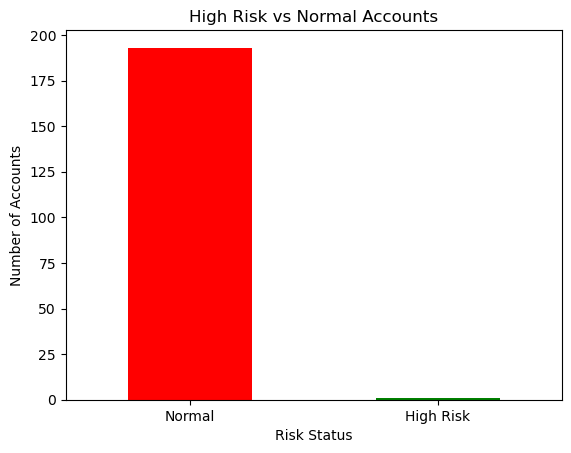

In [83]:
summary["risk_status"].value_counts().plot(
    kind="bar",
    color=["red", "green"]
)

plt.title("High Risk vs Normal Accounts")
plt.xlabel("Risk Status")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=0)
plt.show()

## Calculate balance volatility using standard deviation or coefficient of variation

In [84]:
## Calculate volatility metrics per account
volatility = financial_df.groupby('AccountID').agg({'TransactionAmount1': ['std', 'mean', 'count']}).round(4)

In [85]:
## Add Coefficient of Variation (std/mean)
volatility['CV'] = volatility[('TransactionAmount1', 'std')] / volatility[('TransactionAmount1', 'mean')]
volatility.columns = ['StdDev', 'AvgAmt', 'TxnCount', 'CV']

In [86]:
## Top 50 most volatile (by CV)
high_volatility = volatility.nlargest(50, 'CV')

print("HIGH VOLATILITY ACCOUNTS (CV):")
print(high_volatility[['StdDev', 'AvgAmt', 'CV']].head(10))

HIGH VOLATILITY ACCOUNTS (CV):
               StdDev      AvgAmt        CV
AccountID                                  
ACC57597   41339.2156  31495.0000  1.312564
ACC77592   36854.3043  30664.6667  1.201849
ACC39500   21821.8071  19515.5000  1.118178
ACC86784   29823.6427  26813.5000  1.112262
ACC71426   38223.0438  34439.7500  1.109853
ACC11285   34104.8572  32242.6667  1.057755
ACC45968   74844.4244  74984.0000  0.998139
ACC29231   28798.4424  29417.6667  0.978951
ACC77638   39206.0996  40904.5000  0.958479
ACC45907   54297.9135  56868.2500  0.954802


## Use IQR or z-score methods to detect anomalies

In [89]:
## IQR method
Q1 = financial_df['TransactionAmount1'].quantile(0.25)
Q3 = financial_df['TransactionAmount1'].quantile(0.75)
IQR = Q3 - Q1
anomalies_iqr = financial_df[(financial_df['TransactionAmount1'] < (Q1 - 1.5*IQR)) | (financial_df['TransactionAmount1'] > (Q3 + 1.5*IQR))]

In [90]:
## Z score method for per account
financial_df['ZScore'] = financial_df.groupby('AccountID')['TransactionAmount1'].transform(lambda x: abs(stats.zscore(x)))
anomalies_z = financial_df[financial_df['ZScore'] > 3]

In [92]:
print("IQR ANOMALIES:", len(anomalies_iqr), "txns")
print("Z-SCORE ANOMALIES:", len(anomalies_z), "txns")


IQR ANOMALIES: 0 txns
Z-SCORE ANOMALIES: 0 txns


## Highlight customers with irregular or suspicious transaction behavior

In [93]:
## customer summary
customer_summary = (
   financial_df.groupby("CustomerID")
      .agg(
          total_transactions=("TransactionAmount1", "count"),
          total_spent=("TransactionAmount1", "sum"),
          avg_transaction=("TransactionAmount1", "mean")
      )
      .reset_index()
)


In [94]:
## suspicious using  thresholds
high_spend_threshold = customer_summary["total_spent"].quantile(0.95)
high_tx_threshold = customer_summary["total_transactions"].quantile(0.95)

customer_summary["suspicious"] = (
    (customer_summary["total_spent"] > high_spend_threshold) |
    (customer_summary["total_transactions"] > high_tx_threshold)
)

In [95]:
## Highlight suspicious customers
suspicious_customers = customer_summary[
    customer_summary["suspicious"]
]

suspicious_customers.head(10)

,CustomerID,total_transactions,total_spent,avg_transaction,suspicious
20,CUST1840,8,471852.0,58981.500000,True
51,CUST3015,11,498317.0,45301.545455,True
55,CUST3109,7,500408.0,71486.857143,True
74,CUST4346,8,525633.0,65704.125000,True
76,CUST4373,9,465910.0,51767.777778,True
93,CUST5174,10,603714.0,60371.400000,True
111,CUST5920,7,554942.0,79277.428571,True
160,CUST8390,8,493893.0,61736.625000,True
163,CUST8529,9,535785.0,59531.666667,True
166,CUST8772,9,551250.0,61250.000000,True


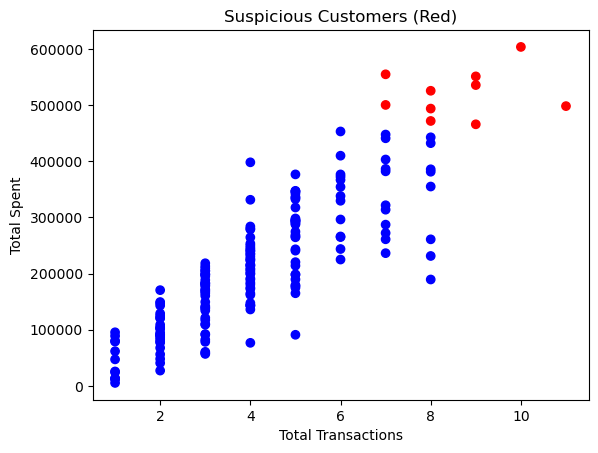

In [98]:
## Visualization
colors = customer_summary["suspicious"].map({True: "red", False: "blue"})

plt.scatter(
    customer_summary["total_transactions"],
    customer_summary["total_spent"],
    c=colors
)

plt.xlabel("Total Transactions")
plt.ylabel("Total Spent")
plt.title("Suspicious Customers (Red)")
plt.show()

Red dots = suspicious
Blue dots = normal


# Task 5: Visualisation

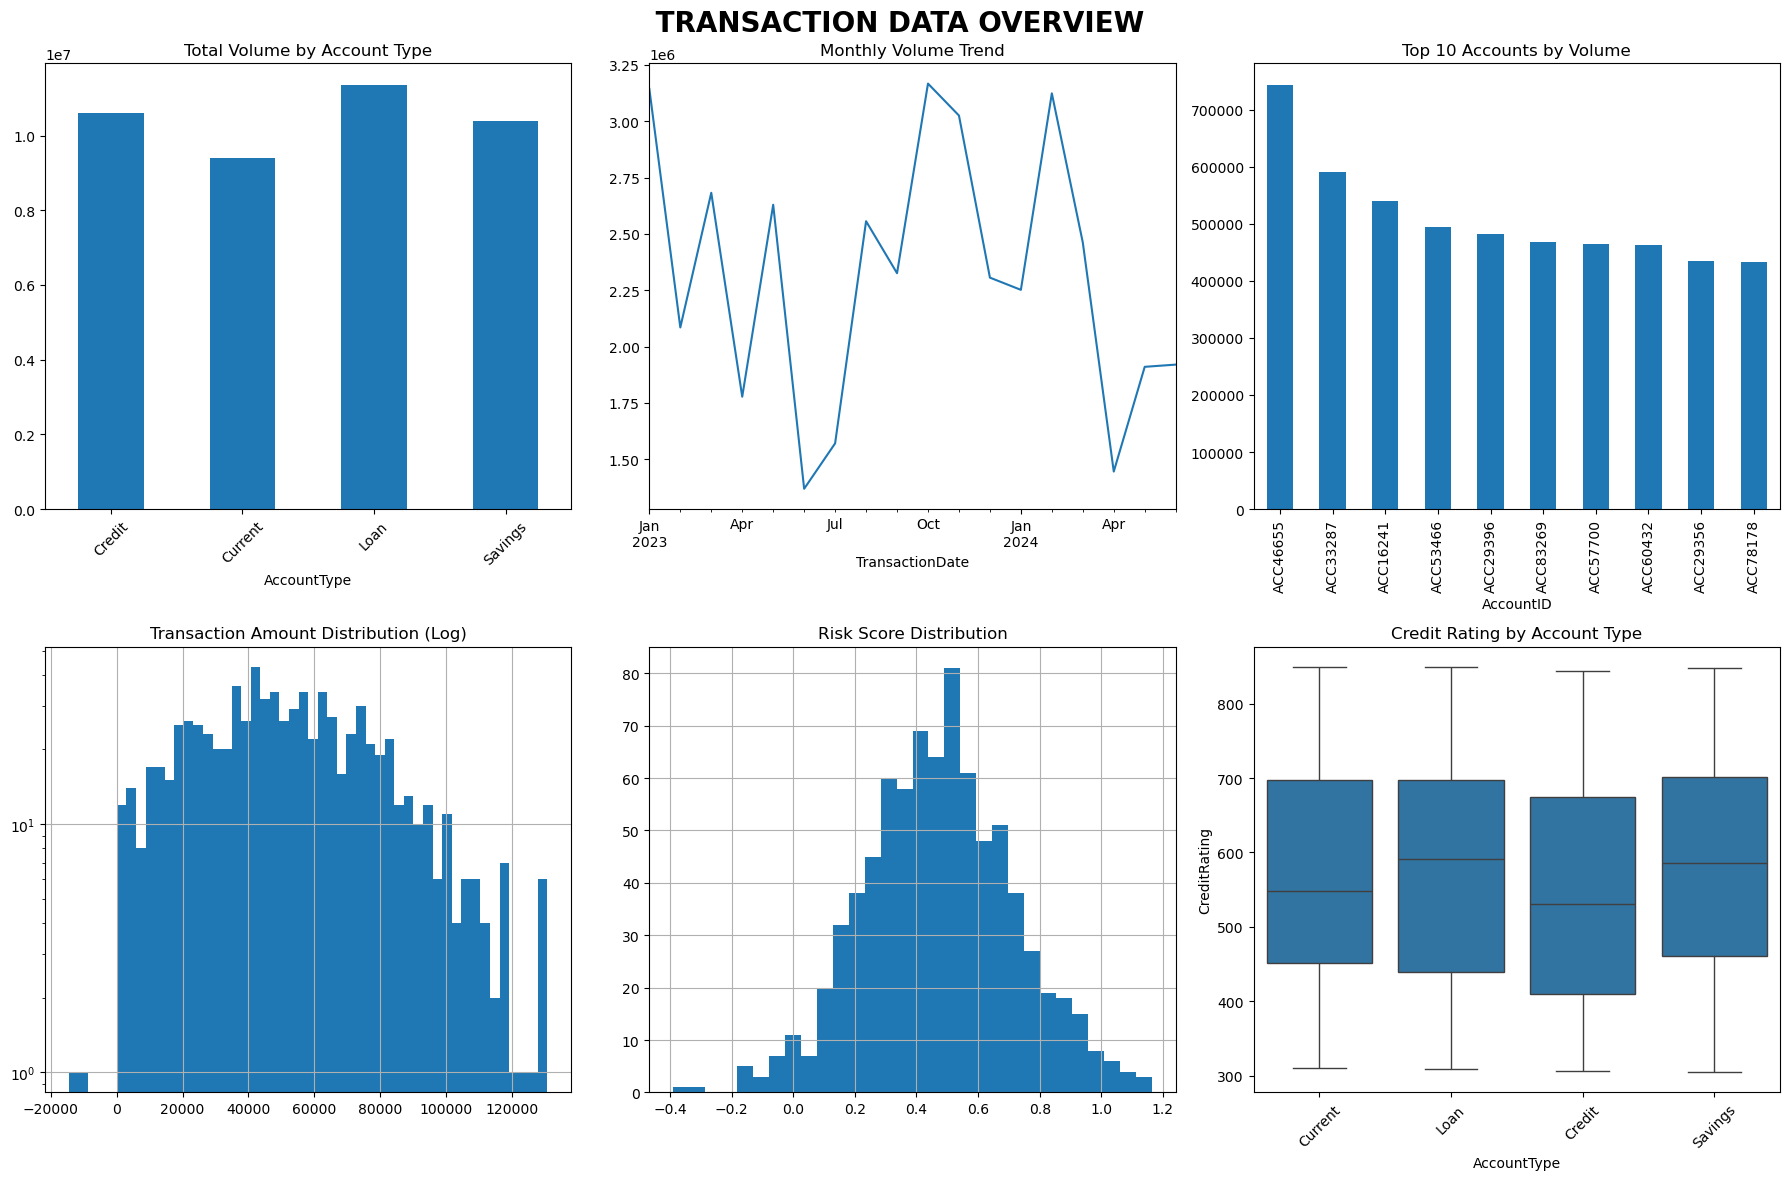

In [101]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(' TRANSACTION DATA OVERVIEW', fontsize=20, fontweight='bold')
financial_df.groupby('AccountType')['TransactionAmount1'].sum().plot(kind='bar', ax=axes[0,0], title='Total Volume by Account Type')
axes[0,0].tick_params(axis='x', rotation=45)
financial_df.groupby( financial_df['TransactionDate'].dt.to_period('M'))['TransactionAmount1'].sum().plot(ax=axes[0,1], title='Monthly Volume Trend')
top_accounts =  financial_df.groupby('AccountID')['TransactionAmount1'].sum().nlargest(10)
top_accounts.plot(kind='bar', ax=axes[0,2], title='Top 10 Accounts by Volume')
financial_df['TransactionAmount1'].hist(bins=50, ax=axes[1,0], log=True)
axes[1,0].set_title('Transaction Amount Distribution (Log)')
financial_df['RiskScore'].hist(ax=axes[1,1], bins=30)
axes[1,1].set_title('Risk Score Distribution')
sns.boxplot(data= financial_df, x='AccountType', y='CreditRating', ax=axes[1,2])
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].set_title('Credit Rating by Account Type')
plt.tight_layout()
plt.show()

## Insights from the graphs above
##### Loan accounts + top 10 accounts = highest financial impact
##### Transaction behavior is seasonal and uneven
##### Concentration risk exists due to few high-volume accounts
##### Financial risk is concentrated in extreme transaction values
##### Most customers are medium risk, enabling targeted controls
##### Credit accounts need stricter credit and transaction monitoring
##### Multi-factor risk assessment is essential



# Task 6: Hypothesis Testing

## Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts

In [6]:
volume = financial_df.groupby('AccountID')['TransactionID'].count()
median_vol = volume.median()

high_vol_accounts = volume[volume > median_vol].index
low_vol_accounts = volume[volume <= median_vol].index

high_vol_bal = financial_df[financial_df['AccountID'].isin(high_vol_accounts)]['TransactionAmount1']
low_vol_bal = financial_df[financial_df['AccountID'].isin(low_vol_accounts)]['TransactionAmount1']

In [7]:
# H0: No difference in avg balances | H1: High-vol has higher balances

t_stat, p_value = stats.ttest_ind(high_vol_bal, low_vol_bal, equal_var=False)

print(f"T-stat: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"High-vol avg: ${high_vol_bal.mean():.2f}")
print(f"Low-vol avg: ${low_vol_bal.mean():.2f}")

if p_value < 0.05:
    print("REJECT H0: High-volume accounts have SIGNIFICANTLY higher balances")
else:
    print("FAIL TO REJECT H0: No significant difference")

T-stat: 0.372
P-value: 0.710
High-vol avg: $-25089.36
Low-vol avg: $-26492.58
FAIL TO REJECT H0: No significant difference


## Conduct hypothesis testing based on segmentation

In [8]:
## Here for segmentation i have taken high and low of volume and balance

segments = {}

In [9]:
## based on high volume and low volume
vol = financial_df.groupby('AccountID')['TransactionID'].count()
median_vol = vol.median()
segments['high_vol'] = financial_df[financial_df['AccountID'].isin(vol[vol > median_vol].index)]['TransactionAmount1']
segments['low_vol'] = financial_df[financial_df['AccountID'].isin(vol[vol <= median_vol].index)]['TransactionAmount1']

In [10]:
## based on high balance and low balance
bal = financial_df.groupby('AccountID')['TransactionAmount1'].mean()
median_bal = bal.median()
segments['high_bal'] = financial_df[financial_df['AccountID'].isin(bal[bal > median_bal].index)]['TransactionAmount1']
segments['low_bal'] = financial_df[financial_df['AccountID'].isin(bal[bal <= median_bal].index)]['TransactionAmount1']

In [11]:
def test_segments(group1, group2, name):
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    return {'Test': name, 'Avg1': group1.mean(), 'Avg2': group2.mean(), 'P-Value': p_val}

results = [
    test_segments(segments['high_vol'], segments['low_vol'], 'High vs Low Volume'),
    test_segments(segments['high_bal'], segments['low_bal'], 'High vs Low Balance')
]

results_df = pd.DataFrame(results)
print("HYPOTHESIS TEST RESULTS:")
print(results_df.round(3))

HYPOTHESIS TEST RESULTS:
                  Test       Avg1       Avg2  P-Value
0   High vs Low Volume -25089.358 -26492.583     0.71
1  High vs Low Balance  -4607.764 -45351.688     0.00


In [12]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Fail to reject the null hypothesis


In [13]:
alpha = 0.05

if p_value > alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Reject the null hypothesis


In [ ]:
## Insights from the test
### High vs Low Volume:
##The p-value is 0.71, which is much larger than 0.05 → no statistically significant difference between the two groups.
 # We fail to reject the null hypothesis.

### High vs Low Balance:
##The p-value is 0.00 (≈ < 0.05) → a statistically significant difference between the two groups.
# We reject the null hypothesis.